In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 88.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv('data_preprocessed.csv')

df.head()

,Unnamed: 0,userName,content,score,at,appVersion,casefolding,text_cleaned,slang,stopwords,sentiment_label
0,0,Trie Sefita,nyari driver sampe setengah jam lebih ga dapet...,1,2021-11-07 07:33:42,4.30.1,nyari driver sampe setengah jam lebih ga dapet...,nyari driver sampe setengah jam lebih ga dapet...,mencari driver sampai setengah jam lebih tidak...,mencari driver setengah jam lebih tidak dapat ...,negative
1,1,Erpi Anto,Sistem gojek aneh aplikasi gojek g pernah di p...,1,2022-10-17 22:38:57,4.54.2,sistem gojek aneh aplikasi gojek g pernah di p...,sistem gojek aneh aplikasi gojek g pernah di p...,sistem gojek aneh aplikasi gojek tidak pernah ...,sistem gojek aneh aplikasi gojek tidak pernah ...,negative
2,2,Ismoy12,Kepada yth pimpinan gojek akhir akhir ini saya...,2,2022-01-23 09:24:36,4.31.1,kepada yth pimpinan gojek akhir akhir ini saya...,kepada yth pimpinan gojek akhir akhir ini saya...,kepada yang terhormat pimpinan gojek akhir akh...,terhormat pimpinan gojek akhir akhir susah sek...,negative
3,3,azyzs downloader,WAHAI KASTAMER ANDA SADAR NGGAK MEMBERI BINTAN...,1,2023-11-06 07:38:03,4.31.1,wahai kastamer anda sadar nggak memberi bintan...,wahai kastamer anda sadar nggak memberi bintan...,wahai kastamer anda sadar enggak memberi binta...,wahai kastamer sadar enggak memberi bintang ba...,negative
4,4,Ade Sofyan,Kecewa pesanan saya tidak lengkap saya mesen m...,1,2023-06-01 05:16:44,4.60.1,kecewa pesanan saya tidak lengkap saya mesen m...,kecewa pesanan saya tidak lengkap saya mesen m...,kecewa pesanan saya tidak lengkap saya memesan...,kecewa pesanan tidak lengkap memesan makanan d...,negative


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       20000 non-null  int64 
 1   userName         20000 non-null  object
 2   content          20000 non-null  object
 3   score            20000 non-null  int64 
 4   at               20000 non-null  object
 5   appVersion       20000 non-null  object
 6   casefolding      20000 non-null  object
 7   text_cleaned     19991 non-null  object
 8   slang            19991 non-null  object
 9   stopwords        19982 non-null  object
 10  sentiment_label  20000 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


In [ ]:
df.describe()

,Unnamed: 0,score
count,20000.000000,20000.000000
mean,9999.500000,3.174050
std,5773.647028,1.823766
min,0.000000,1.000000
25%,4999.750000,1.000000
50%,9999.500000,3.500000
75%,14999.250000,5.000000
max,19999.000000,5.000000


/tmp/ipython-input-2489322293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


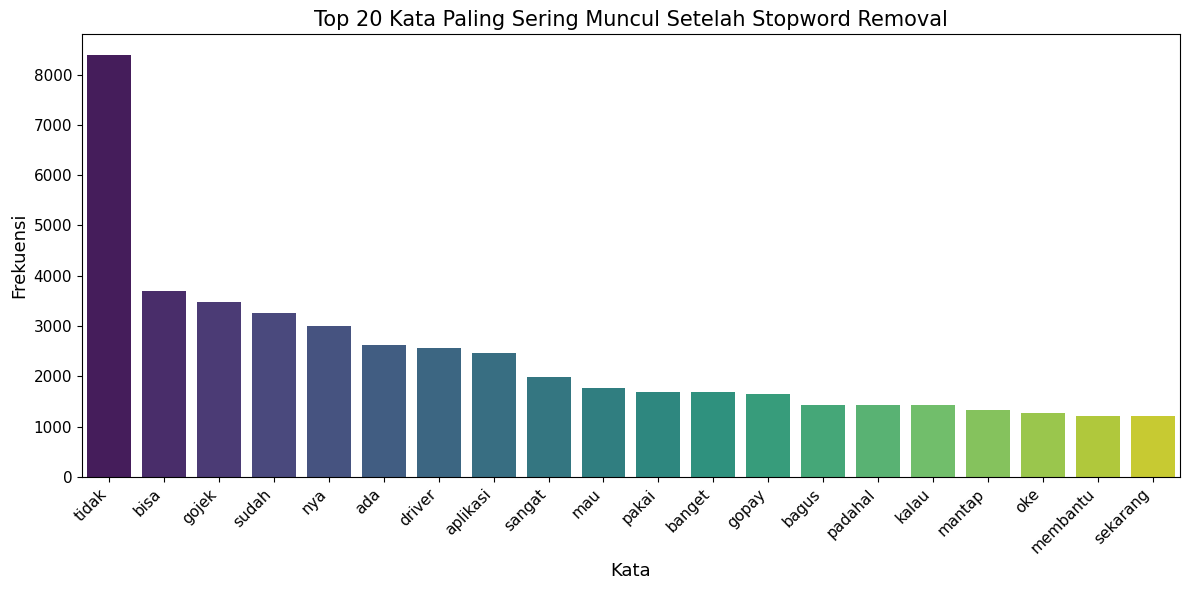

In [ ]:
tokenized_words = [word for text in df['stopwords'].astype(str) for word in text.split()]

top_words = pd.DataFrame(
    Counter(tokenized_words).most_common(20),
    columns=['word', 'frequency']
)

plt.figure(figsize=(12,6))
sns.barplot(
    x='word',
    y='frequency',
    data=top_words,
    palette='viridis'
)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Kata', fontsize=13)
plt.ylabel('Frekuensi', fontsize=13)
plt.title('Top 20 Kata Paling Sering Muncul Setelah Stopword Removal', fontsize=15)
plt.tight_layout()
plt.show()

count    20000.00000
mean         9.45980
std         11.30083
min          1.00000
25%          2.00000
50%          5.00000
75%         13.00000
max         85.00000
Name: word_count, dtype: float64


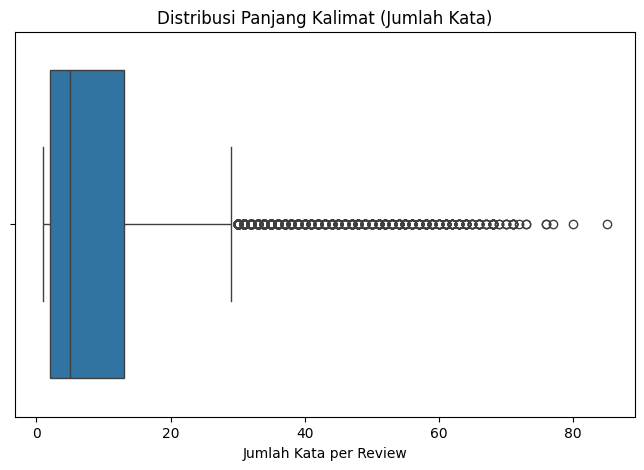

In [ ]:
df['word_count'] = df['stopwords'].astype(str).apply(lambda x: len(x.split()))


print(df['word_count'].describe())

plt.figure(figsize=(8,5))
sns.boxplot(x=df['word_count'])
plt.title("Distribusi Panjang Kalimat (Jumlah Kata)")
plt.xlabel("Jumlah Kata per Review")
plt.show()

In [ ]:
docs = df["stopwords"].astype(str).tolist()

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8,
)

tfidf_matrix = tfidf.fit_transform(docs)

tfidf_mean = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
tfidf_df = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'tfidf_score': tfidf_mean
}).sort_values('tfidf_score', ascending=False)

tfidf_df.head(20)

,word,tfidf_score
2672,mantap,0.049753
3259,oke,0.048788
383,bagus,0.039523
4672,tidak,0.034740
3965,sangat,0.028439
1605,good,0.028394
2838,membantu,0.024160
1517,gojek,0.021202
736,bisa,0.020802
3979,sangat membantu,0.018828


In [ ]:
texts = df['stopwords'].astype(str).apply(lambda x: x.split())

In [ ]:
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

In [ ]:
print(f"Jumlah kata unik dalam dictionary: {len(dictionary)}")

print("\nBeberapa contoh isi dictionary:")
for i in range(20):
    print(f"{i}: {dictionary[i]}")

Jumlah kata unik dalam dictionary: 14566

Beberapa contoh isi dictionary:
0: buang
1: dapat
2: driver
3: jam
4: lebih
5: mencari
6: sangat
7: setengah
8: sungguh
9: tidak
10: waktu
11: ada
12: aktivitas
13: alasan
14: aneh
15: aplikasi
16: bagaimana
17: banding
18: bisa
19: busuk


In [ ]:
coherence_values = []
model_list = []
topics_range = range(2, 11)

for num_topics in topics_range:
    lda_model = LdaModel(corpus=corpus,
                         id2word=dictionary,
                         num_topics=num_topics,
                         random_state=42,
                         passes=10)
    model_list.append(lda_model)
    coherencemodel = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

Topik = 2, Coherence = 0.4963
Topik = 3, Coherence = 0.5767
Topik = 4, Coherence = 0.5452
Topik = 5, Coherence = 0.6085
Topik = 6, Coherence = 0.5666
Topik = 7, Coherence = 0.5518
Topik = 8, Coherence = 0.5468
Topik = 9, Coherence = 0.5306
Topik = 10, Coherence = 0.5399


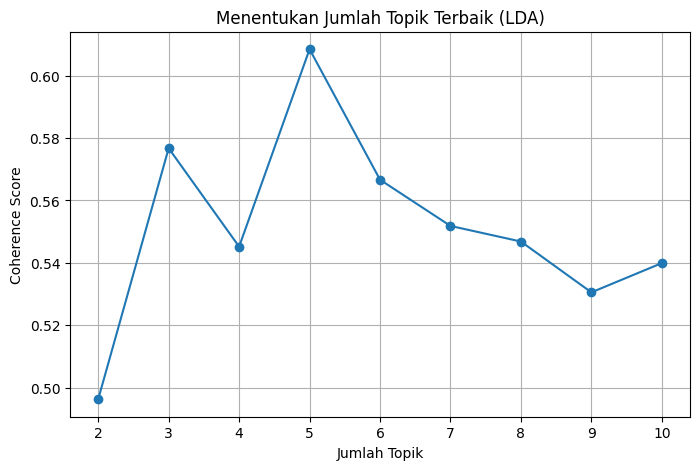

In [ ]:
for t, c in zip(topics_range, coherence_values):
    print(f"Topik = {t}, Coherence = {c:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(topics_range, coherence_values, marker='o')
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score")
plt.title("Menentukan Jumlah Topik Terbaik (LDA)")
plt.grid(True)
plt.show()

In [ ]:
best_num_topics = 5  # Jumlah Topik Terbaik Berdasarkan Coherence Score
lda_best = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=10
)

for idx, topic in lda_best.show_topics(num_topics=best_num_topics, num_words=10, formatted=False):
    print(f"\nTopik {idx+1}:")
    print(", ".join([word for word, _ in topic]))


Topik 1:
baik, promo, gojek, nya, lebih, banyak, tidak, sekarang, mudah, mahal

Topik 2:
sangat, membantu, driver, kasih, gojek, terima, tidak, cepat, nya, ada

Topik 3:
tidak, bisa, sudah, gopay, ada, nya, gojek, pakai, mau, akun

Topik 4:
mantap, good, keren, top, memuaskan, aman, memudahkan, perbanyak, alhamdulillah, job

Topik 5:
bagus, oke, tidak, banget, bisa, aplikasi, gojek, terus, nya, pembaruan


In [ ]:
dominant_topics = []
dominant_probs = []

for row in corpus:
    topic_probs = lda_best.get_document_topics(row)
    top_topic, top_prob = max(topic_probs, key=lambda x: x[1])
    dominant_topics.append(top_topic)
    dominant_probs.append(top_prob)

df['dominant_topic'] = dominant_topics
df['dominant_topic_prob'] = dominant_probs

In [ ]:
df['topic_distribution'] = lda_best.get_document_topics(corpus)

df[['dominant_topic', 'dominant_topic_prob']] = df['topic_distribution'].apply(
    lambda x: pd.Series(max(x, key=lambda y: y[1]))
)

In [ ]:
df['dominant_topic'].value_counts()

,count
dominant_topic,
4.0,4662
1.0,4632
2.0,4241
0.0,3450
3.0,3015


In [ ]:
num_topics = df['dominant_topic'].nunique()
print(f"Jumlah topik yang terdeteksi: {num_topics}")

for topic_num in sorted(df['dominant_topic'].unique()):
    print(f"\nTopik {int(topic_num)}")
    print("-" * 60)

    top_docs = (
        df[df['dominant_topic'] == topic_num]
        .sort_values(by='dominant_topic_prob', ascending=False)
        .head(10)
    )

    for i, row in enumerate(top_docs.itertuples(), start=1):
        print(f"{i}. ({row.dominant_topic_prob:.3f}) {row.content}")


Jumlah topik yang terdeteksi: 5

Topik 0
------------------------------------------------------------
1. (0.984) Entah kenapa jadi ngga nyaman ada mode hemat di pengiriman gofood Memang lebih murah tapi lebih lama banget Ada tambahan biaya lainnya yang hampir sama dengan biaya ongkir Jadi seperti sama saja ada atau tidaknya mode hemat tapi pengiriman lebih lama Mungkin lebih baik tetap ada biaya ongkir normal tapi tidak perlu ada biaya lainnya dan lamanya pengiriman normal seperti biasanya
2. (0.983) Ya ampun gofood skrg biaya lain lainnya bisa smp 11 ribu bahkn lbh lain lainnya itu apa 1 org 11rb yg pake brp byk org kok makin ksini makin byk ini itunya tambah mahal aj parah sih blm ongkirnya jg makin mahaljdi malah makin byk biayakdg males jdinya mo gofood mahal dibiaya lain2nya sm di ongkir dibanding makanannya
3. (0.977) Kenapa gofood pakai promo sekarang batasnya cuman 1 doang dulu bisa pakai promo gopaypesan antar haduh tolong dong kami para pencari makanan murah mulai bangkrut pa

In [ ]:
df.head()

,Unnamed: 0,userName,content,score,at,appVersion,casefolding,text_cleaned,slang,stopwords,sentiment_label,dominant_topic,dominant_topic_prob,topic_distribution
0,0,Trie Sefita,nyari driver sampe setengah jam lebih ga dapet...,1,2021-11-07 07:33:42,4.30.1,nyari driver sampe setengah jam lebih ga dapet...,nyari driver sampe setengah jam lebih ga dapet...,mencari driver sampai setengah jam lebih tidak...,mencari driver setengah jam lebih tidak dapat ...,negative,1.0,0.932741,"[(0, 0.016991643), (1, 0.932741), (2, 0.016840..."
1,1,Erpi Anto,Sistem gojek aneh aplikasi gojek g pernah di p...,1,2022-10-17 22:38:57,4.54.2,sistem gojek aneh aplikasi gojek g pernah di p...,sistem gojek aneh aplikasi gojek g pernah di p...,sistem gojek aneh aplikasi gojek tidak pernah ...,sistem gojek aneh aplikasi gojek tidak pernah ...,negative,2.0,0.624952,"[(2, 0.6249525), (4, 0.36117685)]"
2,2,Ismoy12,Kepada yth pimpinan gojek akhir akhir ini saya...,2,2022-01-23 09:24:36,4.31.1,kepada yth pimpinan gojek akhir akhir ini saya...,kepada yth pimpinan gojek akhir akhir ini saya...,kepada yang terhormat pimpinan gojek akhir akh...,terhormat pimpinan gojek akhir akhir susah sek...,negative,1.0,0.776669,"[(0, 0.010762681), (1, 0.77666914), (2, 0.0106..."
3,3,azyzs downloader,WAHAI KASTAMER ANDA SADAR NGGAK MEMBERI BINTAN...,1,2023-11-06 07:38:03,4.31.1,wahai kastamer anda sadar nggak memberi bintan...,wahai kastamer anda sadar nggak memberi bintan...,wahai kastamer anda sadar enggak memberi binta...,wahai kastamer sadar enggak memberi bintang ba...,negative,1.0,0.898756,"[(1, 0.8987561), (2, 0.08972099)]"
4,4,Ade Sofyan,Kecewa pesanan saya tidak lengkap saya mesen m...,1,2023-06-01 05:16:44,4.60.1,kecewa pesanan saya tidak lengkap saya mesen m...,kecewa pesanan saya tidak lengkap saya mesen m...,kecewa pesanan saya tidak lengkap saya memesan...,kecewa pesanan tidak lengkap memesan makanan d...,negative,1.0,0.515209,"[(0, 0.012643703), (1, 0.5152087), (2, 0.44678..."


In [ ]:
doc_topics = []
for i, row in enumerate(corpus):
    topic_probs = lda_best.get_document_topics(row)
    top_topic = max(topic_probs, key=lambda x: x[1])[0]
    doc_topics.append(top_topic)

df['dominant_topic'] = doc_topics
df[['stopwords', 'dominant_topic']].head(10)

,stopwords,dominant_topic
0,mencari driver setengah jam lebih tidak dapat ...,1
1,sistem gojek aneh aplikasi gojek tidak pernah ...,2
2,terhormat pimpinan gojek akhir akhir susah sek...,1
3,wahai kastamer sadar enggak memberi bintang ba...,1
4,kecewa pesanan tidak lengkap memesan makanan d...,1
5,gomassage tidak ada padahal pijat gara tidak a...,2
6,ongkos kirim gofood nya mahal mahal ongkirnya ...,0
7,biar diwakili bintang,0
8,aplikasi terlalu berat,0
9,gojek perbaikigofood nya makin kesini makin ba...,0


Topik = 2, Coherence = 0.4963
Topik = 3, Coherence = 0.5767
Topik = 4, Coherence = 0.5452
Topik = 5, Coherence = 0.6085
Topik = 6, Coherence = 0.5666
Topik = 7, Coherence = 0.5518
Topik = 8, Coherence = 0.5468
Topik = 9, Coherence = 0.5306
Topik = 10, Coherence = 0.5399


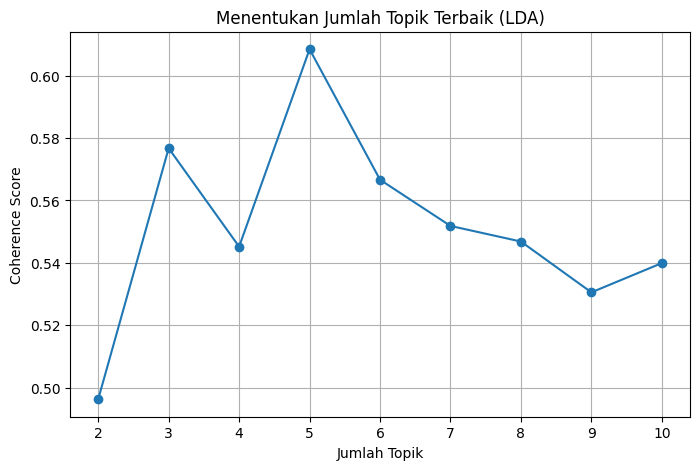

In [ ]:
for t, c in zip(topics_range, coherence_values):
    print(f"Topik = {t}, Coherence = {c:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(topics_range, coherence_values, marker='o')
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score")
plt.title("Menentukan Jumlah Topik Terbaik (LDA)")
plt.grid(True)
plt.show()

In [ ]:
best_index = coherence_values.index(max(coherence_values))
best_num_topics = topics_range[best_index]
best_model = model_list[best_index]

print(f"\nJumlah topik terbaik: {best_num_topics} coherence score = {max(coherence_values):.4f}")


Jumlah topik terbaik: 5 coherence score = 0.6085


In [ ]:
best_num_topics = 5  # Jumlah Topik Terbaik Berdasarkan Coherence Score
lda_best = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=10
)

for idx, topic in lda_best.show_topics(num_topics=best_num_topics, num_words=10, formatted=False):
    print(f"\nTopik {idx+1}:")
    print(", ".join([word for word, _ in topic]))


Topik 1:
baik, promo, gojek, nya, lebih, banyak, tidak, sekarang, mudah, mahal

Topik 2:
sangat, membantu, driver, kasih, gojek, terima, tidak, cepat, nya, ada

Topik 3:
tidak, bisa, sudah, gopay, ada, nya, gojek, pakai, mau, akun

Topik 4:
mantap, good, keren, top, memuaskan, aman, memudahkan, perbanyak, alhamdulillah, job

Topik 5:
bagus, oke, tidak, banget, bisa, aplikasi, gojek, terus, nya, pembaruan


In [ ]:
doc_topics = []
for i, row in enumerate(corpus):
    topic_probs = lda_best.get_document_topics(row)
    top_topic = max(topic_probs, key=lambda x: x[1])[0]
    doc_topics.append(top_topic)

df['dominant_topic'] = doc_topics
df[['stopwords', 'dominant_topic']].head(10)

,stopwords,dominant_topic
0,mencari driver setengah jam lebih tidak dapat ...,1
1,sistem gojek aneh aplikasi gojek tidak pernah ...,2
2,terhormat pimpinan gojek akhir akhir susah sek...,1
3,wahai kastamer sadar enggak memberi bintang ba...,1
4,kecewa pesanan tidak lengkap memesan makanan d...,1
5,gomassage tidak ada padahal pijat gara tidak a...,2
6,ongkos kirim gofood nya mahal mahal ongkirnya ...,0
7,biar diwakili bintang,0
8,aplikasi terlalu berat,0
9,gojek perbaikigofood nya makin kesini makin ba...,0


In [ ]:
num_topics = df['dominant_topic'].nunique()
print(f"Jumlah topik yang terdeteksi: {num_topics}")
for topic_num in sorted(df['dominant_topic'].unique()):
    print(f"\nDominant Topic {topic_num}")
    print("-" * 50)

    sample_texts = df[df['dominant_topic'] == topic_num]['stopwords'].head(10)

    for i, text in enumerate(sample_texts, start=1):
        print(f"{i}. {text}")


Jumlah topik yang terdeteksi: 5

Dominant Topic 0
--------------------------------------------------
1. ongkos kirim gofood nya mahal mahal ongkirnya makanan nya mau jauh mau dekat mahal banget
2. biar diwakili bintang
3. aplikasi terlalu berat
4. gojek perbaikigofood nya makin kesini makin banyak malak parkir padahal jelas resto tidak ada parkir sudah banyak biaya tambahan tambah banyak bohong soal parkir lebih baik kalau memang ada parkir driver langsung ambil gopay ada bukti parkir biar banyak tidak bohong soal parkir bukan uang nya min termasuk suka kasih tips kalau driver tidak jujur malas ganggu menunggu uang parkir baru taro makanan
5. kasih bintang biaya transfer gopay mahal
6. lebih mudah lebih cepat
7. payah bad recommended
8. gapernh dapat diskon gopay
9. tidak ada promo
10. ongkos kirim tidak jelas sekarang jauh dekat sama

Dominant Topic 1
--------------------------------------------------
1. mencari driver setengah jam lebih tidak dapat sungguh sangat buang waktu
2. terho

Distribusi jumlah dokumen per topik:
dominant_topic
0    3451
1    4636
2    4239
3    3014
4    4660
Name: count, dtype: int64

Persentase:
dominant_topic
0    17.26
1    23.18
2    21.20
3    15.07
4    23.30
Name: count, dtype: float64


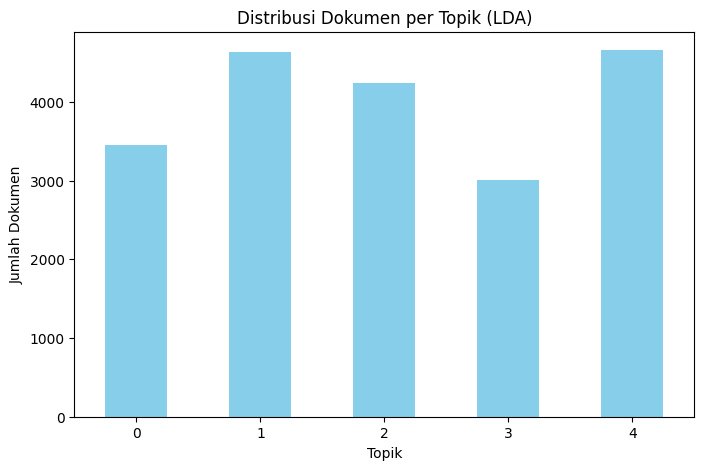

In [ ]:
topic_counts = df['dominant_topic'].value_counts().sort_index()

print("Distribusi jumlah dokumen per topik:")
print(topic_counts)

topic_percentage = (topic_counts / len(df)) * 100
print("\nPersentase:")
print(topic_percentage.round(2))

plt.figure(figsize=(8,5))
topic_counts.plot(kind='bar', color='skyblue')
plt.title("Distribusi Dokumen per Topik (LDA)")
plt.xlabel("Topik")
plt.ylabel("Jumlah Dokumen")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.to_csv("daftar_topik_ldanew.csv", index=False, encoding='utf-8')

In [ ]:
best_num_topics =   # Jumlah Topik Terbaik Berdasarkan Coherence Score
lda_best = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=10
)

for idx, topic in lda_best.show_topics(num_topics=best_num_topics, num_words=10, formatted=False):
    print(f"\nTopik {idx+1}:")
    print(", ".join([word for word, _ in topic]))

In [ ]:
doc_topics = []
for i, row in enumerate(corpus):
    topic_probs = lda_best.get_document_topics(row)
    top_topic = max(topic_probs, key=lambda x: x[1])[0]  # topik dengan probabilitas tertinggi
    doc_topics.append(top_topic)

df['dominant_topic'] = doc_topics
df[['stopwords', 'dominant_topic']].head(10)

,stopwords,dominant_topic
0,mencari driver setengah jam lebih tidak dapat ...,1
1,sistem gojek aneh aplikasi gojek tidak pernah ...,2
2,terhormat pimpinan gojek akhir akhir susah sek...,1
3,wahai kastamer sadar enggak memberi bintang ba...,1
4,kecewa pesanan tidak lengkap memesan makanan d...,1
5,gomassage tidak ada padahal pijat gara tidak a...,2
6,ongkos kirim gofood nya mahal mahal ongkirnya ...,0
7,biar diwakili bintang,5
8,aplikasi terlalu berat,5
9,gojek perbaikigofood nya makin kesini makin ba...,1


Distribusi jumlah dokumen per topik:
dominant_topic
0    3552
1    4553
2    4712
3    2016
4    3559
5    1608
Name: count, dtype: int64

Persentase:
dominant_topic
0    17.76
1    22.76
2    23.56
3    10.08
4    17.79
5     8.04
Name: count, dtype: float64


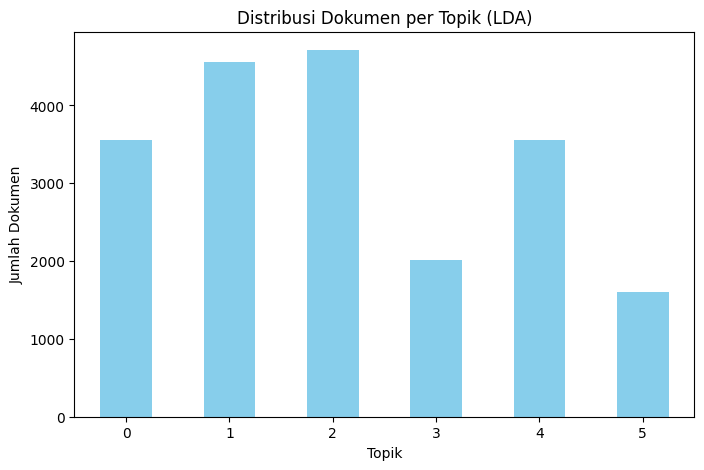

In [ ]:
topic_counts = df['dominant_topic'].value_counts().sort_index()

print("Distribusi jumlah dokumen per topik:")
print(topic_counts)

topic_percentage = (topic_counts / len(df)) * 100
print("\nPersentase:")
print(topic_percentage.round(2))

plt.figure(figsize=(8,5))
topic_counts.plot(kind='bar', color='skyblue')
plt.title("Distribusi Dokumen per Topik (LDA)")
plt.xlabel("Topik")
plt.ylabel("Jumlah Dokumen")
plt.xticks(rotation=0)
plt.show()

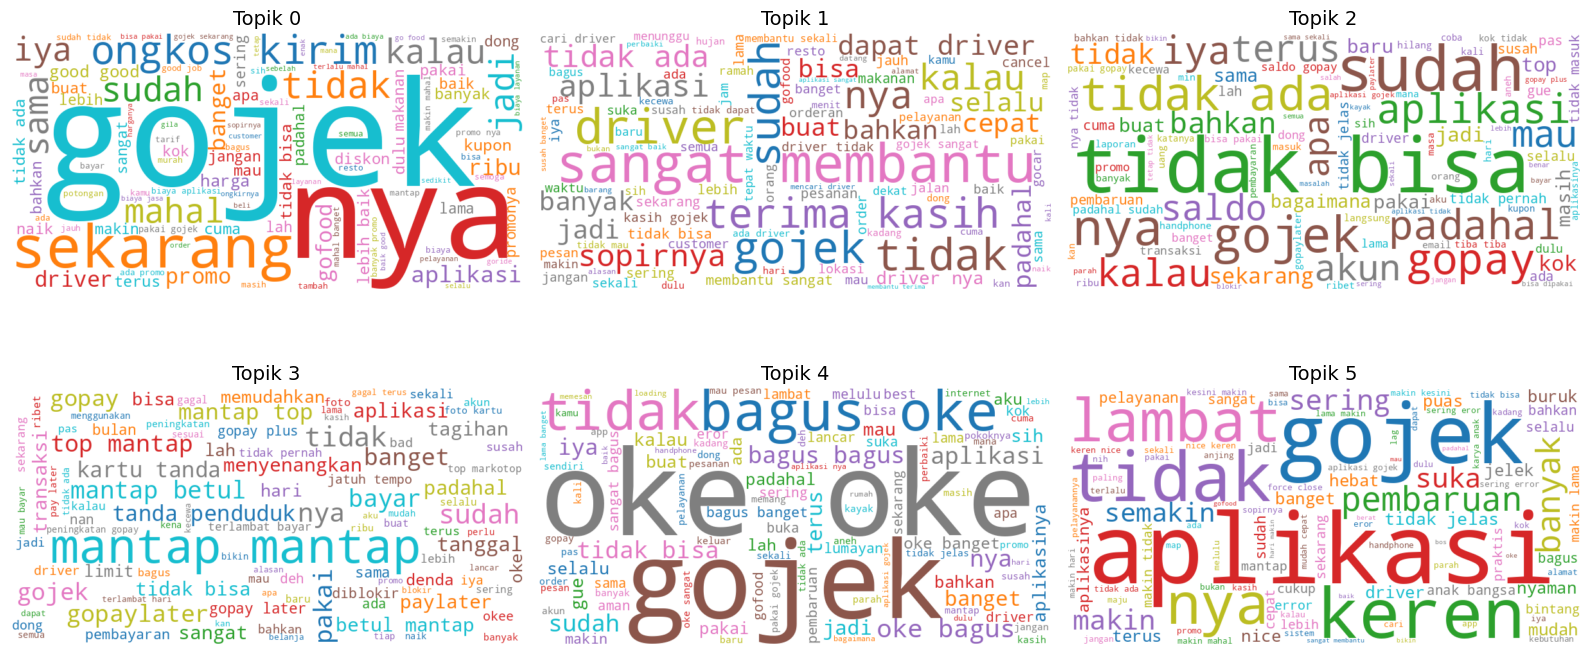

In [ ]:
num_topics = df['dominant_topic'].nunique()

# Buat figure grid untuk semua topik
fig, axes = plt.subplots(2, (num_topics + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for i, topic in enumerate(sorted(df['dominant_topic'].unique())):
    text = " ".join(df[df['dominant_topic'] == topic]['stopwords'].astype(str))
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='tab10',
        max_words=100
    ).generate(text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Topik {topic}", fontsize=14)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
df.to_csv("daftar_topik_lda.csv", index=False, encoding='utf-8')

In [ ]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.6 MB/s eta 0:00:00


In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# === 1. Stopwords dasar dari Sastrawi ===
factory = StopWordRemoverFactory()
sastrawi_stopwords = factory.get_stop_words()

custom_stopwords = [
    'nya','nih','sih','dong','deh','lah','yah','ya','lho','loh',
    'oke','ok','okey','okeylah','baik','banget','sekali','sangat','amat',
    'lumayan','cukup','agak','udah','sudah','belum','masih','udahnya',
    'kayak','kayanya','gitu','gini','begitu','begini','jadi','buat',
    'bikin','mau','akan','ingin','bisa','tidak','tak','gak','ga','enggak',
    'boleh','harus','perlu','dapat','mungkin','apalagi','seperti','misalnya',
    'contohnya','terus','kemudian','karena','jika','kalau','padahal',
    'bahkan','namun','tapi','walaupun','meskipun','sehingga','agar',
    'supaya','biar','kalo','soalnya','jadiin','macam','dst','dll','dsb',
    'dan','atau','serta','dengan','untuk','dari','ke','pada','dalam','oleh',
    'sama','tanpa','hingga','antara',
    'aku','kamu','anda','dia','mereka','saya','gua','gw','loe','lu',
    'itu','ini','tersebut','yang','sebuah','seorang','sebagai',
    'bagus','jelek','parah','mantap','top','hebat','buruk','keren','baik',
    'mantaplah','super','wow','nice','great','amazing','terbaik','terparah',
    'memuaskan','menyenangkan','kecewa','puas','tidakpuas','lambat','cepat',
    'lemot','buruk','error','bug','crash',
    'terima','kasih','makasih','thanks','thankyou','thank','you',
    'yaudah','ywdh','wkwk','haha','hehe','huhu','btw','cmn','cuma','doang',
    'aja','juga','kok','kan','toh','dong','lah','deh',
    'sekarang','dulu','nanti','besok','kemarin','hari','waktu','jam','tahun',
    'bulan','hariini','kemaren','baru','lagi','selalu'
]

all_stopwords = set(sastrawi_stopwords + custom_stopwords)

import re

def remove_stopwords(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    filtered = [word for word in tokens if word not in all_stopwords]
    return " ".join(filtered)

df['text_akhir'] = df['stopwords'].fillna("").apply(remove_stopwords)

df.head()

,Unnamed: 0,userName,content,score,at,appVersion,casefolding,text_cleaned,slang,stopwords,sentiment_label,word_count,dominant_topic,text_akhir
0,0,Trie Sefita,nyari driver sampe setengah jam lebih ga dapet...,1,2021-11-07 07:33:42,4.30.1,nyari driver sampe setengah jam lebih ga dapet...,nyari driver sampe setengah jam lebih ga dapet...,mencari driver sampai setengah jam lebih tidak...,mencari driver setengah jam lebih tidak dapat ...,negative,11,1,mencari driver setengah lebih sungguh buang
1,1,Erpi Anto,Sistem gojek aneh aplikasi gojek g pernah di p...,1,2022-10-17 22:38:57,4.54.2,sistem gojek aneh aplikasi gojek g pernah di p...,sistem gojek aneh aplikasi gojek g pernah di p...,sistem gojek aneh aplikasi gojek tidak pernah ...,sistem gojek aneh aplikasi gojek tidak pernah ...,negative,43,2,sistem gojek aneh aplikasi gojek pernah pakai ...
2,2,Ismoy12,Kepada yth pimpinan gojek akhir akhir ini saya...,2,2022-01-23 09:24:36,4.31.1,kepada yth pimpinan gojek akhir akhir ini saya...,kepada yth pimpinan gojek akhir akhir ini saya...,kepada yang terhormat pimpinan gojek akhir akh...,terhormat pimpinan gojek akhir akhir susah sek...,negative,18,1,terhormat pimpinan gojek akhir akhir susah dri...
3,3,azyzs downloader,WAHAI KASTAMER ANDA SADAR NGGAK MEMBERI BINTAN...,1,2023-11-06 07:38:03,4.31.1,wahai kastamer anda sadar nggak memberi bintan...,wahai kastamer anda sadar nggak memberi bintan...,wahai kastamer anda sadar enggak memberi binta...,wahai kastamer sadar enggak memberi bintang ba...,negative,52,1,wahai kastamer sadar memberi bintang bawah ken...
4,4,Ade Sofyan,Kecewa pesanan saya tidak lengkap saya mesen m...,1,2023-06-01 05:16:44,4.60.1,kecewa pesanan saya tidak lengkap saya mesen m...,kecewa pesanan saya tidak lengkap saya mesen m...,kecewa pesanan saya tidak lengkap saya memesan...,kecewa pesanan tidak lengkap memesan makanan d...,negative,15,1,pesanan lengkap memesan makanan datang satu ba...


In [ ]:
texts = df['text_akhir'].astype(str).apply(lambda x: x.split())

dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

In [ ]:
print(f"Jumlah kata unik dalam dictionary: {len(dictionary)}")

print("\nBeberapa contoh isi dictionary:")
for i in range(20):
    print(f"{i}: {dictionary[i]}")

Jumlah kata unik dalam dictionary: 14468

Beberapa contoh isi dictionary:
0: buang
1: driver
2: lebih
3: mencari
4: setengah
5: sungguh
6: aktivitas
7: alasan
8: aneh
9: aplikasi
10: bagaimana
11: banding
12: busuk
13: dipakai
14: giliran
15: gojek
16: gopatner
17: jelas
18: makin
19: now


In [ ]:
coherence_values = []
model_list = []
topics_range = range(3, 11)

for num_topics in topics_range:
    lda_model = LdaModel(corpus=corpus,
                         id2word=dictionary,
                         num_topics=num_topics,
                         random_state=42,
                         passes=10)
    model_list.append(lda_model)
    coherencemodel = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

Topik = 3, Coherence = 0.5452
Topik = 4, Coherence = 0.5026
Topik = 5, Coherence = 0.5290
Topik = 6, Coherence = 0.4832
Topik = 7, Coherence = 0.5145
Topik = 8, Coherence = 0.4852
Topik = 9, Coherence = 0.5497
Topik = 10, Coherence = 0.5186


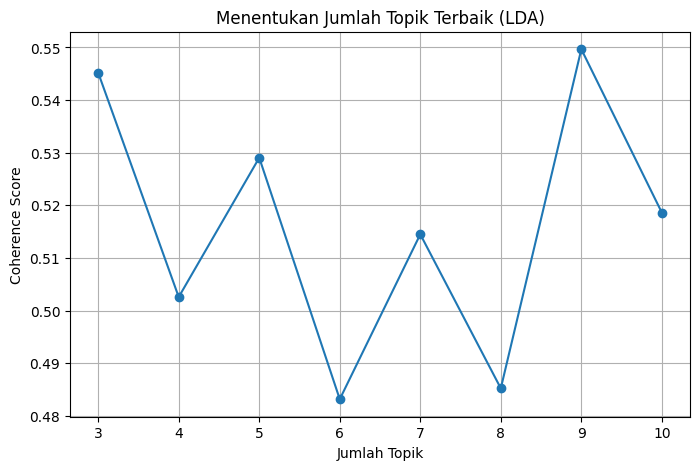

In [ ]:
for t, c in zip(topics_range, coherence_values):
    print(f"Topik = {t}, Coherence = {c:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(topics_range, coherence_values, marker='o')
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score")
plt.title("Menentukan Jumlah Topik Terbaik (LDA)")
plt.grid(True)
plt.show()

In [ ]:
best_num_topics = 9
lda_best = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=10
)

for idx, topic in lda_best.show_topics(num_topics=best_num_topics, num_words=10, formatted=False):
    print(f"\nTopik {idx+1}:")
    print(", ".join([word for word, _ in topic]))


Topik 1:
gopay, pakai, saldo, bayar, akun, tiba, gojek, apa, gopaylater, transaksi

Topik 2:
good, jauh, driver, ribu, jalan, naik, lokasi, tujuan, dekat, gojek

Topik 3:
aplikasi, gojek, semoga, biaya, suka, semakin, layanan, sukses, banyak, lebih

Topik 4:
gojek, mudah, go, senang, anak, bintang, pakai, semua, best, iya

Topik 5:
membantu, pelayanan, nyaman, sopan, perjalanan, tingkatkan, gojek, gerak, sok, malas

Topik 6:
driver, sopirnya, gojek, ramah, pesan, susah, lama, menunggu, order, sip

Topik 7:
aplikasi, pembaruan, aplikasinya, masuk, sering, iya, buka, keluar, gojek, jelas

Topik 8:
promo, makin, banyak, pakai, gofood, kupon, gojek, lebih, mahal, diskon

Topik 9:
handphone, no, perbanyak, login, nomor, email, akun, pin, ganti, mohon


In [ ]:
doc_topics = []
for i, row in enumerate(corpus):
    topic_probs = lda_best.get_document_topics(row)
    top_topic = max(topic_probs, key=lambda x: x[1])[0]  # topik dengan probabilitas tertinggi
    doc_topics.append(top_topic)

df['dominant_topic'] = doc_topics
df[['text_akhir', 'dominant_topic']].head(10)

,text_akhir,dominant_topic
0,mencari driver setengah lebih sungguh buang,5
1,sistem gojek aneh aplikasi gojek pernah pakai ...,0
2,terhormat pimpinan gojek akhir akhir susah dri...,5
3,wahai kastamer sadar memberi bintang bawah ken...,1
4,pesanan lengkap memesan makanan datang satu ba...,5
5,gomassage pijat gara go masage uninstall,1
6,ongkos kirim gofood mahal mahal ongkirnya maka...,7
7,diwakili bintang,3
8,aplikasi terlalu berat,1
9,gojek perbaikigofood makin kesini makin banyak...,1


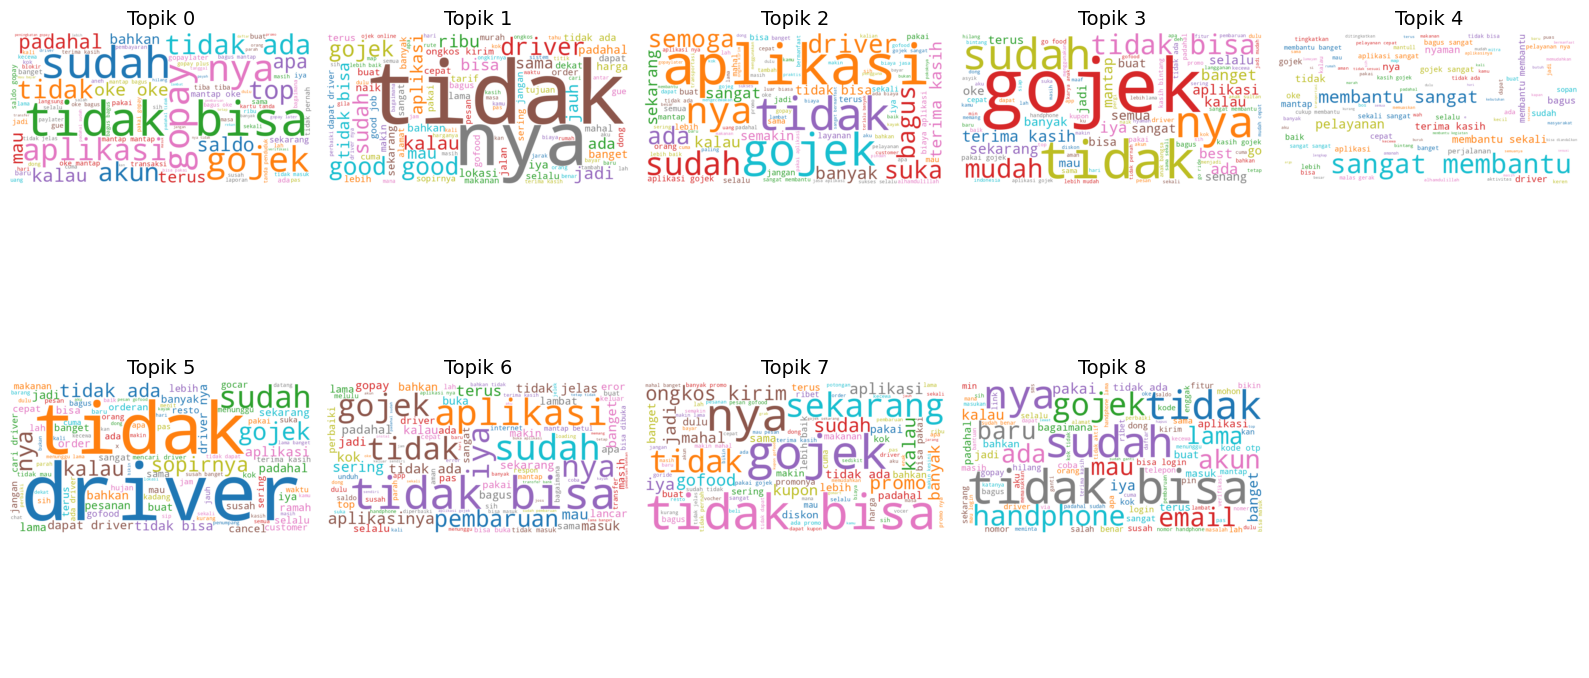

In [ ]:
num_topics = df['dominant_topic'].nunique()

# Buat figure grid untuk semua topik
fig, axes = plt.subplots(2, (num_topics + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for i, topic in enumerate(sorted(df['dominant_topic'].unique())):
    text = " ".join(df[df['dominant_topic'] == topic]['stopwords'].astype(str))
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='tab10',
        max_words=100
    ).generate(text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Topik {topic}", fontsize=14)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


Distribusi jumlah dokumen per topik:
dominant_topic
0    6247
1    1875
2    1521
3    1207
4    1450
5    2221
6    1896
7    2266
8    1317
Name: count, dtype: int64

Persentase:
dominant_topic
0    31.24
1     9.38
2     7.60
3     6.04
4     7.25
5    11.10
6     9.48
7    11.33
8     6.59
Name: count, dtype: float64


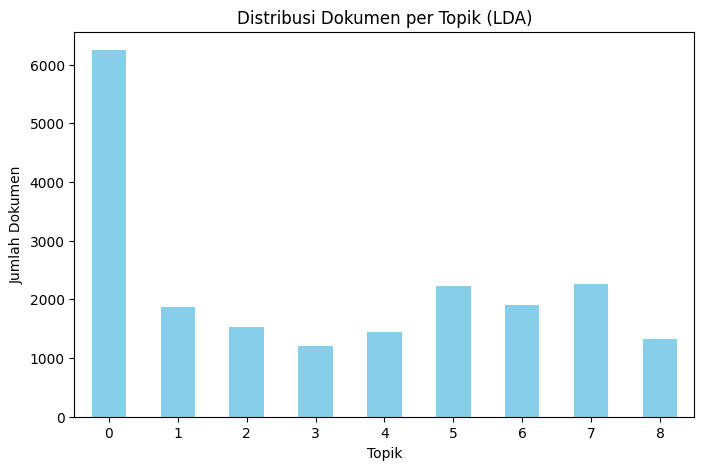

In [ ]:
topic_counts = df['dominant_topic'].value_counts().sort_index()

print("Distribusi jumlah dokumen per topik:")
print(topic_counts)

topic_percentage = (topic_counts / len(df)) * 100
print("\nPersentase:")
print(topic_percentage.round(2))

plt.figure(figsize=(8,5))
topic_counts.plot(kind='bar', color='skyblue')
plt.title("Distribusi Dokumen per Topik (LDA)")
plt.xlabel("Topik")
plt.ylabel("Jumlah Dokumen")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.to_csv("daftar_topik_lda(stopwords).csv", index=False, encoding='utf-8')

In [ ]:
mask = (
    df['stopwords'].astype(str).str.contains(r'\bgo\b', case=False, regex=True, na=False) &
    df['stopwords'].astype(str).str.contains(r'\bjek\b', case=False, regex=True, na=False) &
    ~df['stopwords'].astype(str).str.contains(r'gojek', case=False, regex=True, na=False)
)

filtered_df = df[mask]
print(filtered_df)


       Unnamed: 0                userName  \
866           866  Tommy Indoprabu Negoro   
1651         1651              Apel Merah   
2155         2155             ༺ꗴRᎾNᎯLDᎾꗴ༻   
4371         4371       Eko indra Fratama   
7444         7444         Misriyah Sa'dun   
7570         7570         Arkan & Thalita   
11080       11080         Padliansyah 080   
12622       12622           Alena Gristin   
13225       13225       Tomi Imam Raharjo   
17025       17025           Muhamad Muhdy   
17541       17541             Ahmad Fauzi   
18617       18617            Nino Andi_20   
19013       19013            dodi nugraha   

                                                 content  score  \
866    Daftar susah2 minta password berkali2 uda gitu...      2   
1651   Pesan makanan buat anak tidak dapat di medan  ...      1   
2155   Bukan Lagi Seperti Dulu Pesan Makanan Nihhh Go...      2   
4371   Sya gk bisa masuk apk go jek lg gara2 no sya h...      2   
7444                            Gk

In [ ]:
df['stopwords'] = df['stopwords'].astype(str).str.replace(r'\bgo\s+jek\b', 'gojek', case=False, regex=True)

changed_rows = df[df['stopwords'].str.contains('gojek', case=False, regex=True)]
print(changed_rows)

       Unnamed: 0          userName  \
1               1         Erpi Anto   
2               2           Ismoy12   
9               9   Cici Indriani20   
11             11     Riri Trinanda   
26             26        Gc Kloter3   
...           ...               ...   
19913       19913       Iis Sartika   
19926       19926  iqbal Al-Jemberi   
19932       19932        Lie Winata   
19945       19945     zaenal abidin   
19994       19994          LEVUP TV   

                                                 content  score  \
1      Sistem gojek aneh aplikasi gojek g pernah di p...      1   
2      Kepada yth pimpinan gojek akhir akhir ini saya...      2   
9      Tolong gojek di perbaikigofood nya makin kesin...      1   
11     Gojek update otomatis 3hari lalu Dan tidak bis...      1   
26     Hallo gojek saya top up Facebook Ads melalui G...      1   
...                                                  ...    ...   
19913  Menurut saya System sekarang kurang baik Aplik...      

In [ ]:
mask_nya = df['stopwords'].astype(str).str.contains(r'\bnya\b', case=False, regex=True, na=False)

filtered_df = df[mask_nya]
print(filtered_df)

       Unnamed: 0            userName  \
1               1           Erpi Anto   
6               6  chania prima nanda   
9               9     Cici Indriani20   
19             19         Nanda Yulia   
25             25            lia juli   
...           ...                 ...   
19913       19913         Iis Sartika   
19956       19956     Fahrina Alfahri   
19968       19968     Fhilip Alifiano   
19979       19979               Uu Ws   
19987       19987       Ochid Belanda   

                                                 content  score  \
1      Sistem gojek aneh aplikasi gojek g pernah di p...      1   
6      Ongkir gofood nya pada mahal Mahal ongkirnya d...      1   
9      Tolong gojek di perbaikigofood nya makin kesin...      1   
19     Sudah beberapa kali pesan gofood DOMINO PIZZA ...      1   
25                  susah banget daftar ny hapus lagi aj      1   
...                                                  ...    ...   
19913  Menurut saya System sekarang ku

In [ ]:
count_nya = mask_nya.sum()
print(count_nya)

2289


In [ ]:
df['stopwords'] = df['stopwords'].astype(str).str.replace(r'\bnya\b', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()

filtered_df = df[mask_nya]
count_nya = mask_nya.sum()
print(count_nya)

2289


In [ ]:
count_standalone_nya = df['stopwords'].astype(str).str.count(r'\bnya\b').sum()
print("Total kemunculan 'nya' yang berdiri sendiri:", count_standalone_nya)

Total kemunculan 'nya' yang berdiri sendiri: 0


In [ ]:
coherence_values = []
model_list = []
topics_range = range(2, 11)

for num_topics in topics_range:
    lda_model = LdaModel(corpus=corpus,
                         id2word=dictionary,
                         num_topics=num_topics,
                         random_state=42,
                         passes=10)
    model_list.append(lda_model)
    coherencemodel = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

Topik = 2, Coherence = 0.5300
Topik = 3, Coherence = 0.5042
Topik = 4, Coherence = 0.5512
Topik = 5, Coherence = 0.5185
Topik = 6, Coherence = 0.5555
Topik = 7, Coherence = 0.5219
Topik = 8, Coherence = 0.5500
Topik = 9, Coherence = 0.5433
Topik = 10, Coherence = 0.5225


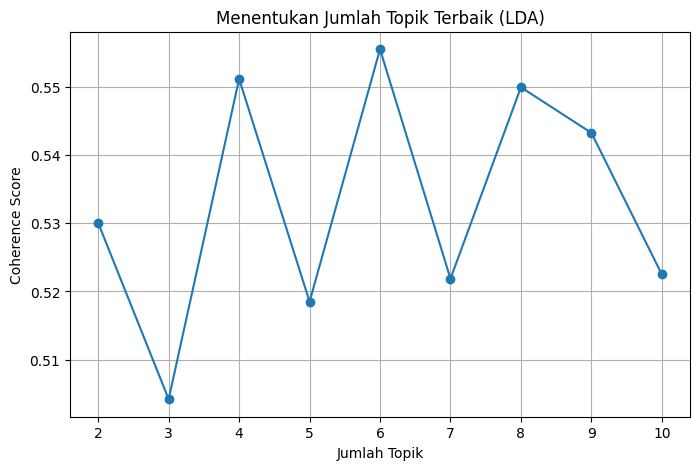

In [ ]:
for t, c in zip(topics_range, coherence_values):
    print(f"Topik = {t}, Coherence = {c:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(topics_range, coherence_values, marker='o')
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score")
plt.title("Menentukan Jumlah Topik Terbaik (LDA)")
plt.grid(True)
plt.show()

In [ ]:
best_num_topics = 6
lda_best = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=10
)

for idx, topic in lda_best.show_topics(num_topics=best_num_topics, num_words=10, formatted=False):
    print(f"\nTopik {idx+1}:")
    print(", ".join([word for word, _ in topic]))


Topik 1:
good, suka, go, keren, nyaman, banget, kadang, pokoknya, terbaik, food

Topik 2:
gojek, aplikasi, semua, puas, aman, selalu, sukses, ada, bermanfaat, online

Topik 3:
tidak, mantap, bisa, sudah, gopay, ada, gojek, pakai, mau, aplikasi

Topik 4:
promo, makin, banyak, mahal, gojek, sekarang, tidak, biaya, pakai, gofood

Topik 5:
oke, driver, tidak, kalau, pesan, banget, gojek, ada, dapat, sudah

Topik 6:
sangat, bagus, membantu, kasih, terima, baik, gojek, cepat, aplikasi, sekali


In [ ]:
doc_topics = []
for i, row in enumerate(corpus):
    topic_probs = lda_best.get_document_topics(row)
    top_topic = max(topic_probs, key=lambda x: x[1])[0]  # topik dengan probabilitas tertinggi
    doc_topics.append(top_topic)

df['dominant_topic'] = doc_topics
df[['stopwords', 'dominant_topic']].head(10)

,stopwords,dominant_topic
0,mencari driver setengah jam lebih tidak dapat ...,4
1,sistem gojek aneh aplikasi gojek tidak pernah ...,2
2,terhormat pimpinan gojek akhir akhir susah sek...,4
3,wahai kastamer sadar enggak memberi bintang ba...,4
4,kecewa pesanan tidak lengkap memesan makanan d...,4
5,gomassage tidak ada padahal pijat gara tidak a...,2
6,ongkos kirim gofood mahal mahal ongkirnya maka...,3
7,biar diwakili bintang,3
8,aplikasi terlalu berat,3
9,gojek perbaikigofood makin kesini makin banyak...,3


Distribusi jumlah dokumen per topik:
dominant_topic
0    1956
1     978
2    6662
3    2339
4    4184
5    3881
Name: count, dtype: int64

Persentase:
dominant_topic
0     9.78
1     4.89
2    33.31
3    11.70
4    20.92
5    19.40
Name: count, dtype: float64


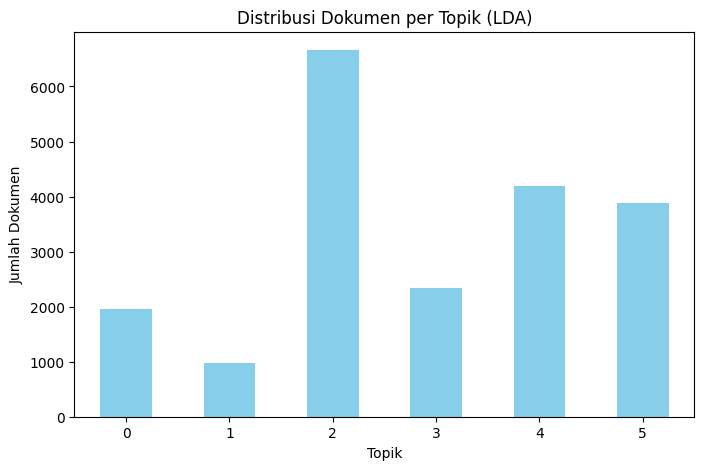

In [ ]:
topic_counts = df['dominant_topic'].value_counts().sort_index()

print("Distribusi jumlah dokumen per topik:")
print(topic_counts)

topic_percentage = (topic_counts / len(df)) * 100
print("\nPersentase:")
print(topic_percentage.round(2))

plt.figure(figsize=(8,5))
topic_counts.plot(kind='bar', color='skyblue')
plt.title("Distribusi Dokumen per Topik (LDA)")
plt.xlabel("Topik")
plt.ylabel("Jumlah Dokumen")
plt.xticks(rotation=0)
plt.show()